# Midterm project: расход топлива автомобилей (Vehicle fuel efficiency)

## Этап 1. Постановка задачи (Problem and scope)

**Вопрос проекта:** можно ли предсказать комбинированный расход топлива нового легкового автомобиля по его базовым характеристикам (год выпуска, объём двигателя, число цилиндров, класс, тип трансмиссии, тип топлива)?

**Тип задачи:** регрессия.
**Target (зафиксирован):** `Combined (L/100 km)`: комбинированный расход, л на 100 км.

**Метрики:**
- **MAE** (л/100 км): основная метрика, легко интерпретируется;
- **RMSE** (л/100 км): сильнее штрафует крупные ошибки;
- **R²**: доля объяснённой дисперсии.

**Критерий успеха:** MAE лучшей модели на test как минимум на 50% ниже MAE baseline (предсказание среднего значения target на train). Порог можно уточнить после первых результатов.

**Контекст и объём:** данные Natural Resources Canada за 2014-2025 годы (11829 строк). В данных нет веса и мощности автомобиля, поэтому вместо них модели опираются на объём двигателя, число цилиндров и класс автомобиля. Это ограничение учитываем при анализе ошибок. План: очистка и EDA, feature engineering, split с защитой от утечки (group split по паре `Make` + `Model`), baseline, Linear Regression, Decision Tree, KNN, cross-validation, анализ ошибок.

# Этап 2. Загрузка и первичный осмотр данных

**Источник данных:** Natural Resources Canada, Fuel Consumption Ratings (Open Canada), официальная страница набора: https://open.canada.ca/data/en/dataset/98f1a129-f628-4ce4-b24d-6f16bf24dd64
**Лицензия:** Open Government Licence - Canada.
**Откуда загружаем в коде:** копия этих данных в GitHub-репозитории `bgl2427/fuel-efficiency`, файл `fuel_consumption_2014_2025.csv` (ссылка `CSV_URL` в ячейке ниже). Размер: 11829 строк, 15 столбцов, около 960 КБ. Годы 2015-2024 мы сверили с официальным файлом 2015-2024: число строк по годам, распределение `Fuel type`, статистика target и число пропусков совпадают. Для 2014 и 2025 отдельной сверки с официальным файлом не делали.
**Что используем:** весь файл, модельные годы **2014-2025** (11829 строк, 15 столбцов): основной набор для обучения и тестирования. Файлы 1995-2013 не смешиваем: у них рейтинги пересчитаны по другой методике.
**Известные особенности:** нет веса и мощности; `CO2 rating` и `Smog rating` пропущены за первые годы; несколько столбцов напрямую выражают target (см. 3.7).

**Как получаем данные:**
1. `pd.read_csv` читает CSV прямо по ссылке `CSV_URL`, локальные файлы не нужны, поэтому ноутбук запускается у всех участников одинаково.
2. `df.columns.str.strip()` убирает случайные пробелы в названиях столбцов.

In [21]:
import pandas as pd

CSV_URL = "https://raw.githubusercontent.com/bgl2427/fuel-efficiency/refs/heads/main/fuel_consumption_2014_2025.csv"
df = pd.read_csv(CSV_URL)
df.columns = df.columns.str.strip()

### Размер данных

`df.shape` показывает число строк и столбцов.

**Результат:** (11829, 15), то есть 11829 автомобилей и 15 столбцов.
**Вывод:** для Linear Regression, Decision Tree и KNN этого достаточно, модели обучаются быстро.

In [22]:
print(df.shape)

(11829, 15)


### Типы данных и пропуски

`df.info()` показывает тип каждого столбца и сколько в нём непустых значений.

**Результат:**
- Типы: 6 столбцов float64, 4 int64, 5 текстовых (`object`).
- Пропуски есть только в двух столбцах: `CO2 rating` (9633 из 11829 заполнены) и `Smog rating` (8527 из 11829).

**Вывод:** оба столбца с пропусками мы всё равно не берём в признаки из-за утечки данных (см. ниже), поэтому заполнять пропуски не нужно.

In [23]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11829 entries, 0 to 11828
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model year            11829 non-null  int64  
 1   Make                  11829 non-null  object 
 2   Model                 11829 non-null  object 
 3   Vehicle class         11829 non-null  object 
 4   Engine size (L)       11829 non-null  float64
 5   Cylinders             11829 non-null  int64  
 6   Transmission          11829 non-null  object 
 7   Fuel type             11829 non-null  object 
 8   City (L/100 km)       11829 non-null  float64
 9   Highway (L/100 km)    11829 non-null  float64
 10  Combined (L/100 km)   11829 non-null  float64
 11  Combined (mpg)        11829 non-null  int64  
 12  CO2 emissions (g/km)  11829 non-null  int64  
 13  CO2 rating            9633 non-null   float64
 14  Smog rating           8527 non-null   float64
dtypes: float64(6), int6

### Первые строки

`df.head()` показывает первые 5 строк, чтобы увидеть, как выглядят данные.

**Что видно:**
- Данные начинаются с 2014 года, значит, загружен весь файл 2014-2025.
- `Vehicle class` содержит составные названия (например, `Compact` и `Sport utility vehicle: Small`). Единообразие записи проверим в 3.3.
- `Transmission` состоит из типа и числа передач (`AS5`, `M6`, `AV7`): из неё можно сделать два признака.
- `Fuel type` закодирован буквами.
- В названии модели встречаются гибриды (например, `ILX Hybrid`).

In [24]:
print(df.head())

   Model year   Make       Model                 Vehicle class  \
0        2014  Acura         ILX                       Compact   
1        2014  Acura         ILX                       Compact   
2        2014  Acura  ILX Hybrid                       Compact   
3        2014  Acura     MDX 4WD  Sport utility vehicle: Small   
4        2014  Acura     RDX AWD  Sport utility vehicle: Small   

   Engine size (L)  Cylinders Transmission Fuel type  City (L/100 km)  \
0              2.0          4          AS5         Z              9.9   
1              2.4          4           M6         Z             11.2   
2              1.5          4          AV7         Z              6.0   
3              3.5          6          AS6         Z             12.7   
4              3.5          6          AS6         Z             12.1   

   Highway (L/100 km)  Combined (L/100 km)  Combined (mpg)  \
0                 6.7                  8.5              33   
1                 7.7                  9

### Список столбцов

`df.columns.tolist()` выводит точные названия столбцов, чтобы обращаться к ним в коде без опечаток.

**Кандидаты в признаки:** `Model year`, `Make`, `Model`, `Vehicle class`, `Engine size (L)`, `Cylinders`, `Transmission`, `Fuel type`.

**Target:** `Combined (L/100 km)`.

**Исключаем из признаков (data leakage):** `City (L/100 km)`, `Highway (L/100 km)`, `Combined (mpg)`, `CO2 emissions (g/km)`, `CO2 rating`, `Smog rating`. Они напрямую выражают target или считаются из него, и модель получила бы ответ вместо того, чтобы его предсказывать.

In [25]:
print(df.columns.tolist())

['Model year', 'Make', 'Model', 'Vehicle class', 'Engine size (L)', 'Cylinders', 'Transmission', 'Fuel type', 'City (L/100 km)', 'Highway (L/100 km)', 'Combined (L/100 km)', 'Combined (mpg)', 'CO2 emissions (g/km)', 'CO2 rating', 'Smog rating']


### Диапазон лет, типы топлива и статистика

В ячейке три проверки:
1. Минимум и максимум года. **Результат:** 2014 и 2025.
2. `value_counts()` по `Fuel type`. **Результат:** X: 5574, Z: 5559, E: 423, D: 272, N: 1. Категории очень разной частоты, а `N` встречается всего один раз (решение по нему примем при очистке). Расшифровка букв по документации NRCan: X: regular gasoline, Z: premium gasoline, D: diesel, E: ethanol (E85), N: natural gas. Сверьте с Data Dictionary на странице набора данных.
3. `describe()`: минимум, максимум, среднее по числовым столбцам.

**Что видно в `describe()`:**
- Target `Combined (L/100 km)`: от 4.0 до 26.1, среднее около 11.0, std около 2.9. Разброс достаточный, чтобы было что предсказывать.
- Объём двигателя 0.9-8.4 л, цилиндры 3-16: значения правдоподобны, явных ошибок не видно.

**Ограничение датасета (limitation):** в данных нет веса и мощности автомобиля.
**Чем заменяем вес и мощность:** тема проекта упоминает вес и мощность, но в данных их нет. Объём двигателя, число цилиндров и класс автомобиля (`Vehicle class`) косвенно отражают размер и мощность машины, поэтому используем их. Auto MPG (UCI) можно рассмотреть как дополнительный набор на финал.

In [26]:
print(df["Model year"].min(), df["Model year"].max())
print(df["Fuel type"].value_counts())
df.describe()

2014 2025
Fuel type
X    5574
Z    5559
E     423
D     272
N       1
Name: count, dtype: int64


,Model year,Engine size (L),Cylinders,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating
count,11829.000000,11829.000000,11829.000000,11829.000000,11829.000000,11829.000000,11829.000000,11829.000000,9633.00000,8527.000000
mean,2019.109984,3.153496,5.621354,12.537417,9.183380,11.028439,27.371375,254.023586,4.61362,4.824675
std,3.355525,1.340000,1.865467,3.481807,2.246852,2.881756,7.381000,61.066271,1.55905,1.751139
min,2014.000000,0.900000,3.000000,4.000000,3.900000,4.000000,11.000000,94.000000,1.00000,1.000000
25%,2016.000000,2.000000,4.000000,10.100000,7.600000,9.000000,22.000000,209.000000,4.00000,3.000000
50%,2019.000000,3.000000,6.000000,12.200000,8.900000,10.700000,26.000000,250.000000,5.00000,5.000000
75%,2022.000000,3.700000,6.000000,14.600000,10.400000,12.700000,31.000000,292.000000,5.00000,6.000000
max,2025.000000,8.400000,16.000000,30.700000,20.900000,26.100000,71.000000,608.000000,10.00000,8.000000


# Этап 3. Очистка данных
Проверяем: дубликаты, пропуски, диапазоны, категории, подозрительные признаки (leakage).
Каждое решение записываем с причиной.

## 3.1 Дубликаты

**Что проверяем:** есть ли в таблице полностью одинаковые строки (совпадают все 15 столбцов).
**Зачем:** повторяющиеся строки учили бы модель на одних и тех же данных несколько раз и делали бы оценку качества менее честной.
**Как:** `df.duplicated().sum()` считает повторные копии строк.

In [27]:
# Сколько полностью одинаковых строк (вторая и последующие копии)
print("Дубликатов:", df.duplicated().sum())
# Показываем все копии, чтобы понять, ошибка это или реальные машины
df[df.duplicated(keep=False)].sort_values(["Make", "Model", "Model year"]).head(10)

Дубликатов: 0


,Model year,Make,Model,Vehicle class,Engine size (L),Cylinders,Transmission,Fuel type,City (L/100 km),Highway (L/100 km),Combined (L/100 km),Combined (mpg),CO2 emissions (g/km),CO2 rating,Smog rating


**Результат:** найдено 0 дубликатов (`df.duplicated().sum()` = 0). Вторая часть ячейки вернула пустую таблицу, потому что копий строк нет.

**Решение:** ничего не удаляем.

**Причина:** полностью одинаковых строк нет, поэтому модель не увидит одни и те же данные несколько раз, и оценка качества не будет искажена повторами.

## 3.2 Пропуски в CO2 rating и Smog rating

**Что делаем:** считаем для каждого года, сколько рейтингов пропущено.

**Зачем:** проверяем гипотезу, что пропуски связаны с годом (рейтинг не публиковался), а не разбросаны случайно.
Это нужно, чтобы понимать причину пропусков, даже если мы их не заполняем.

In [28]:
# Для каждого года: сколько машин всего и сколько пропусков в рейтингах
by_year = df.groupby("Model year").agg(
    rows=("Model year", "size"),
    co2_rating_missing=("CO2 rating", lambda s: s.isna().sum()),
    smog_rating_missing=("Smog rating", lambda s: s.isna().sum()),
)
print(by_year)

            rows  co2_rating_missing  smog_rating_missing
Model year                                               
2014        1068                1068                 1068
2015        1128                1128                 1128
2016        1106                   0                 1106
2017        1058                   0                    0
2018        1083                   0                    0
2019        1056                   0                    0
2020         975                   0                    0
2021         970                   0                    0
2022         976                   0                    0
2023         919                   0                    0
2024         789                   0                    0
2025         701                   0                    0


**Результат:** пропуски в рейтингах связаны с годом, а не разбросаны случайно:
- `CO2 rating` пропущен во всех строках 2014 и 2015 годов (1068 + 1128 = 2196), начиная с 2016 года пропусков нет;
- `Smog rating` пропущен во всех строках 2014, 2015 и 2016 годов (1068 + 1128 + 1106 = 3302), начиная с 2017 года пропусков нет.

Гипотеза подтвердилась: для этих лет значений в файле нет.

**Решение:** пропуски не заполняем и строки с ними не удаляем.

**Причина:** столбцы `CO2 rating` и `Smog rating` уйдут из признаков как leakage (они почти напрямую выражают target), поэтому заполнять их нет смысла. Строки 2014-2016 годов при этом сохраняются: мы убираем только столбцы, а не машины, и не теряем 3302 наблюдения.

## 3.3 Категориальные столбцы

**Что делаем:** смотрим, какие значения встречаются в `Vehicle class`, `Transmission` и `Fuel type`, и проверяем текстовые столбцы на лишние пробелы и разный регистр.

**Зачем:** модели работают с числами, поэтому текстовые категории позже придётся кодировать. Если одна и та же категория записана по-разному (например `Compact` и `compact `), кодировщик посчитает их разными, и признак станет менее информативным.

**Как:** `value_counts()` показывает все значения и их частоту. Проверка пробелов и регистра сравнивает число уникальных значений до и после приведения к единому виду.

In [29]:
# Трансмиссия: уникальные коды и их частота
df["Transmission"].value_counts()

Transmission
AS8     2285
AS6     1494
M6      1210
A8       945
A6       857
AM7      787
A9       699
AS10     569
AV       507
AS7      341
A10      324
AM8      296
M5       208
AS9      187
AM6      177
AV6      164
AV7      156
M7       152
AV8      144
A5        84
A4        65
A7        58
AV10      46
AS5       34
AV1       28
AM9        6
AM5        4
AS4        2
Name: count, dtype: int64

In [30]:
# Классы автомобилей и сколько машин в каждом
print(df["Vehicle class"].value_counts())

Vehicle class
Sport utility vehicle: Small       2203
Mid-size                           1639
Sport utility vehicle: Standard    1482
Compact                            1360
Pickup truck: Standard             1015
Subcompact                          964
Full-size                           894
Two-seater                          753
Minicompact                         535
Station wagon: Small                333
Pickup truck: Small                 240
Minivan                             117
Special purpose vehicle             110
Station wagon: Mid-size              92
Van: Passenger                       70
Van: Cargo                           22
Name: count, dtype: int64


In [31]:
# Если "уникальных" и "после приведения" совпадают, проблем с пробелами и регистром нет
for col in ["Make", "Model", "Vehicle class", "Transmission", "Fuel type"]:
    n_space = (df[col] != df[col].str.strip()).sum()
    n_unique = df[col].nunique()
    n_unique_norm = df[col].str.strip().str.lower().nunique()
    print(col, "| с лишними пробелами:", n_space,
          "| уникальных:", n_unique, "| после приведения:", n_unique_norm)

Make | с лишними пробелами: 0 | уникальных: 44 | после приведения: 44
Model | с лишними пробелами: 22 | уникальных: 2294 | после приведения: 2268
Vehicle class | с лишними пробелами: 0 | уникальных: 16 | после приведения: 16
Transmission | с лишними пробелами: 0 | уникальных: 28 | после приведения: 28
Fuel type | с лишними пробелами: 0 | уникальных: 5 | после приведения: 5


**Результат:**
- `Make`: 44 значения, `Vehicle class`: 16, `Transmission`: 28, `Fuel type`: 5. Пробелов и разного регистра в этих столбцах нет, значения до и после приведения совпадают.
- `Model`: у 22 строк лишние пробелы по краям, из 2294 уникальных названий после приведения остаётся 2268. Разбор в 3.5.
- Редкие значения есть в `Transmission` (`AS4`: 2, `AM5`: 4, `AM9`: 6) и в `Vehicle class` (`Van: Cargo`: 22), а также среди марок (например, `SRT`: 2 строки).

**Решение:** `Make`, `Vehicle class`, `Transmission` не меняем, редкие категории не объединяем и не удаляем.
**Причина:** это не ошибки записи, а реальные модели. Трансмиссию позже разберём на тип и число передач, что снимет проблему редких кодов. Кодировщик настроим на неизвестные категории, потому что редкие значения могут оказаться только в test.

## 3.4 Fuel type = N

**Что делаем:** смотрим на единственную строку с типом топлива `N`.

**Зачем:** одна строка на 11829 ничему не научит модель. При разбиении на train и test она может попасть только в одну часть, и тогда кодировщик встретит неизвестную категорию. Нужно решить, что с ней делать.

In [32]:
# Единственная строка с Fuel type = N
print(df[df["Fuel type"] == "N"])

# Удаляем её и проверяем размер
print("До:", df.shape)
df = df[df["Fuel type"] != "N"].reset_index(drop=True)
print("После:", df.shape)
print(df["Fuel type"].value_counts())

      Model year       Make             Model Vehicle class  Engine size (L)  \
2432        2016  Chevrolet  Impala Dual Fuel      Mid-size              3.6   

      Cylinders Transmission Fuel type  City (L/100 km)  Highway (L/100 km)  \
2432          6          AS6         N             15.2                 9.5   

      Combined (L/100 km)  Combined (mpg)  CO2 emissions (g/km)  CO2 rating  \
2432                 12.7              22                   213         6.0   

      Smog rating  
2432          NaN  
До: (11829, 15)
После: (11828, 15)
Fuel type
X    5574
Z    5559
E     423
D     272
Name: count, dtype: int64


**Результат:** единственная строка с `N` это Chevrolet Impala Dual Fuel 2016 (3.6 л, 6 цилиндров, AS6). После удаления в таблице 11828 строк и 4 типа топлива: X (5574), Z (5559), E (423), D (272).

**Решение:** удаляем эту строку.

**Причина:** одна строка не позволит модели выучить закономерность. Объединять `N` с другой категорией нельзя, это другой вид топлива. Потеря около 0,01% данных.

## 3.5 Названия моделей (Model)

**Что делаем:** ищем в `Model` лишние пробелы и разный регистр у одинаковых названий.

**Зачем:** пару `Make` + `Model` мы планируем использовать для group split. Если одна модель записана по-разному, она попадёт в разные группы, и почти одинаковые машины окажутся и в train, и в test (leakage).


In [33]:
# Строки с пробелами по краям (repr показывает кавычки, пробелы видны)
bad = df[df["Model"] != df["Model"].str.strip()]
print("Строк с пробелами:", len(bad))
bad["Model"].map(repr).head(10)

Строк с пробелами: 22


2779               'XF AWD '
5078                 'CX-5 '
6529           'A6 quattro '
6530           'A6 quattro '
6531           'A6 allroad '
6533                  'A8L '
6534                  'A8L '
7183         'A 220 4MATIC '
7195    'AMG CLA 35 4MATIC '
7196    'AMG CLA 45 4MATIC '
Name: Model, dtype: object

In [34]:
# Уникальных названий: после strip и после strip + lower
s = df["Model"].str.strip()
print("после strip:", s.nunique(), "| после strip + lower:", s.str.lower().nunique())

после strip: 2283 | после strip + lower: 2268


In [35]:
# Названия, совпадающие без учёта регистра, но записанные по-разному
low = s.str.lower()
n_variants = s.groupby(low).nunique()
for key in n_variants[n_variants > 1].index:
    print(sorted(s[low == key].unique()))

['ALPINA B8 Gran Coupe', 'Alpina B8 Gran Coupe']
['ALPINA XB7', 'Alpina XB7']
['F-PACE P250', 'F-Pace P250']
['F-PACE P400', 'F-Pace P400']
['F-PACE P550 SVR', 'F-Pace P550 SVR']
['GranTurismo', 'Granturismo']
['GranTurismo Convertible', 'Granturismo Convertible']
['Huracan EVO Coupe', 'Huracan evo Coupe']
['Huracan EVO Coupe AWD', 'Huracan evo Coupe AWD']
['Huracan EVO Spyder', 'Huracan evo Spyder']
['Huracan EVO Spyder AWD', 'Huracan evo Spyder AWD']
['LaCrosse', 'Lacrosse']
['LaCrosse AWD', 'Lacrosse AWD']
['LaCrosse eAssist', 'Lacrosse eAssist']
['Tacoma 4WD D-Cab TRD Off-Road/PRO', 'Tacoma 4WD D-Cab TRD Off-Road/Pro']


In [36]:
# Сколько уникальных пар Make + Model до приведения регистра
pairs_before = df[["Make", "Model"]].drop_duplicates().shape[0]

# Приводим к нижнему регистру (пробелы уже убраны)
df["Model"] = df["Model"].str.lower()

# Проверка: пар должно стать ровно на 12 меньше
pairs_after = df[["Make", "Model"]].drop_duplicates().shape[0]
print("Пар Make+Model: до", pairs_before, "| после", pairs_after,
      "| убрано", pairs_before - pairs_after)
print("Уникальных Model:", df["Model"].nunique())

Пар Make+Model: до 2295 | после 2280 | убрано 15
Уникальных Model: 2279


**Результат:**
- В `Model` у 22 строк лишние пробелы по краям. После `strip` число уникальных названий снизилось с 2294 до 2283, после `strip` + `lower` их 2268.
- 15 названий записаны с разным регистром у одной и той же модели (например `LaCrosse` и `Lacrosse`, `F-PACE P250` и `F-Pace P250`, `Huracan EVO Coupe` и `Huracan evo Coupe`).
- В ячейке выше к `Model` применён только `lower()`: пар `Make` + `Model` стало 2280 вместо 2295 (убрано 15), уникальных названий 2279. Названия, отличающиеся только пробелом в конце (11 названий, 22 строки), пока остаются разными. При `strip` + `lower` было бы 2268 названий и 2269 пар.
- Пар на одну больше, чем названий: одно и то же название встречается у двух разных марок.

**Решение:** привели `Model` к нижнему регистру. Пробелы по краям в 22 строках в `df` пока не убраны.
**Причина:** это одни и те же автомобили, записанные по-разному. Для group split они попали бы в разные группы, и почти одинаковые машины оказались бы одновременно в train и в test (leakage). Группировать нужно по паре `Make` + `Model`, а не по одному `Model`: иначе две разные машины с одинаковым названием у разных марок склеились бы. Сам `Model` как признак не используем, названий слишком много.

## 3.6 Диапазоны и выбросы
**Что делаем:** смотрим минимум и максимум ключевых числовых столбцов.
**Зачем:** найти физически невозможные значения (нулевой двигатель, отрицательный расход). Большие и маленькие, но реальные значения удалять нельзя.

In [37]:
# Диапазоны ключевых числовых столбцов
df[["Engine size (L)", "Cylinders", "Combined (L/100 km)"]].describe()

,Engine size (L),Cylinders,Combined (L/100 km)
count,11828.000000,11828.000000,11828.000000
mean,3.153458,5.621322,11.028297
std,1.340050,1.865542,2.881837
min,0.900000,3.000000,4.000000
25%,2.000000,4.000000,9.000000
50%,3.000000,6.000000,10.700000
75%,3.700000,6.000000,12.700000
max,8.400000,16.000000,26.100000


**Результат:** по 11828 строкам: `Engine size` 0.9-8.4 л, `Cylinders` 3-16, `Combined (L/100 km)` 4.0-26.1 (среднее около 11, std около 2.9). Нулей и отрицательных значений нет.
**Решение:** выбросы не удаляем.
**Причина:** высокий расход у мощных машин и низкий у гибридов это реальные автомобили, а не ошибки. Удалять стоит только физически невозможные значения, а таких нет.

## 3.7 Столбцы с утечкой (leakage)
**Что делаем:** фиксируем список столбцов, которые нельзя использовать как признаки.

**Зачем:** большая часть этих столбцов почти напрямую выражает target `Combined (L/100 km)`: `City` и `Highway` это его составные части, `Combined (mpg)` это тот же расход в других единицах, `CO2 emissions` рассчитывается из расхода по коэффициенту для типа топлива, `CO2 rating` выводится из CO2. Модель получила бы ответ в подсказке и показала бы красивые, но ложные результаты. `Smog rating` с расходом напрямую не связан, но мы его тоже убираем: это официальная оценка, а не характеристика автомобиля, и она пропущена за 2014-2016 годы.

**Как:** сохраняем список в `leak_cols`. Из `df` пока не удаляем, они нужны для EDA (корреляционная матрица покажет проблему). Удалим при сборке признаков.

In [38]:
leak_cols = [
    "City (L/100 km)", "Highway (L/100 km)", "Combined (mpg)",
    "CO2 emissions (g/km)", "CO2 rating", "Smog rating",
]
print(leak_cols)

['City (L/100 km)', 'Highway (L/100 km)', 'Combined (mpg)', 'CO2 emissions (g/km)', 'CO2 rating', 'Smog rating']


**Результат:** в `leak_cols` зафиксированы 6 столбцов: `City (L/100 km)`, `Highway (L/100 km)`, `Combined (mpg)`, `CO2 emissions (g/km)`, `CO2 rating`, `Smog rating`.

**Решение:** эти столбцы не станут признаками. В `df` они пока остаются.

**Причина:** пять из шести столбцов выражают target напрямую или через пересчёт, шестой (`Smog rating`) убираем по правилу проекта и из-за пропусков. Оставляем их до EDA, чтобы показать на корреляционной матрице, почему они дали бы утечку. Из таблицы признаков удалим при сборке признаков (этап 5), до split и до любого `fit`.

## Итог этапа 3
- **Строк:** было 11829, стало 11828 (удалена 1 строка с `Fuel type = N`).
- **Дубликаты:** нет.
- **Пропуски:** только `CO2 rating` (2014-2015) и `Smog rating` (2014-2016). Не заполняем, оба столбца в `leak_cols`.
- **Категории:** `Vehicle class`, `Transmission`, `Make` не меняем, редкие значения видны в `value_counts` (3.3). В `Model` привели регистр (15 вариантов написания). Пробелы по краям (22 строки) пока не убраны.
- **Выбросы:** смотрели минимум и максимум, не удаляли, невозможных значений нет.
- **Leakage:** в `leak_cols` зафиксированы 6 столбцов, которые не станут признаками.
- **Заметки на следующие этапы:** разобрать `Transmission` на тип и число передач (у `AV` без числа 507 строк); для group split использовать пару `Make` + `Model`; кодировщик настроить на неизвестные категории из-за редких значений в `Vehicle class`, `Transmission` и `Make`.

# Этап 4. EDA

Строим 5 графиков, у каждого короткий вывод. Target: `Combined (L/100 km)`.
Данные после очистки: 11828 строк, модельные годы 2014-2025.

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
TARGET = "Combined (L/100 km)"
print(df.shape)

(11828, 15)


### 4.1 Распределение target

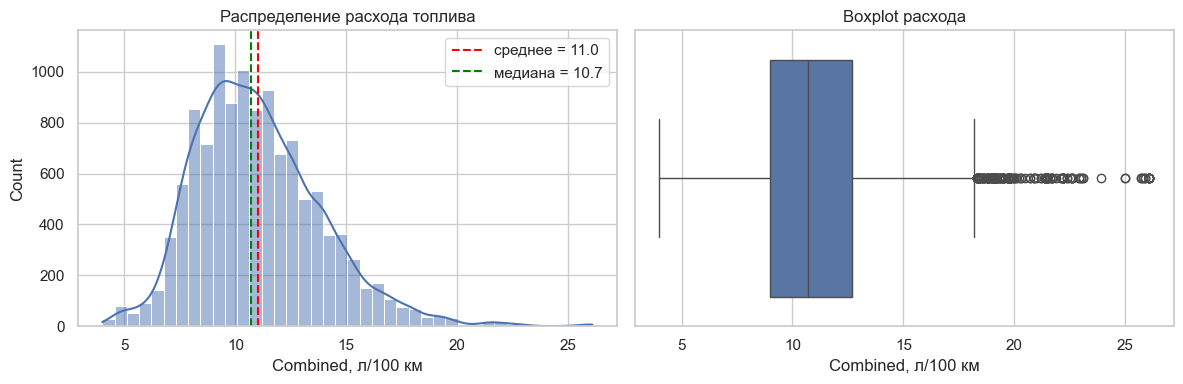

count    11828.00
mean        11.03
std          2.88
min          4.00
25%          9.00
50%         10.70
75%         12.70
max         26.10
Name: Combined (L/100 km), dtype: float64
Асимметрия (skew): 0.81


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[TARGET], bins=40, kde=True, ax=axes[0])
axes[0].axvline(df[TARGET].mean(), color="red", linestyle="--", label=f"среднее = {df[TARGET].mean():.1f}")
axes[0].axvline(df[TARGET].median(), color="green", linestyle="--", label=f"медиана = {df[TARGET].median():.1f}")
axes[0].set_title("Распределение расхода топлива")
axes[0].set_xlabel("Combined, л/100 км")
axes[0].legend()

sns.boxplot(x=df[TARGET], ax=axes[1])
axes[1].set_title("Boxplot расхода")
axes[1].set_xlabel("Combined, л/100 км")

plt.tight_layout()
plt.show()

print(df[TARGET].describe().round(2))
print("Асимметрия (skew):", round(df[TARGET].skew(), 2))

**Вывод:**
- Распределение скошено вправо (skew 0.81): большинство машин расходует 9-12.7 л/100 км (25% и 75% квантили), правый хвост тянется до 26.1.
- Среднее 11.03 больше медианы 10.7 из-за хвоста. Std 2.88.
- Точки справа на boxplot это реальные мощные машины (V8, V12, фургоны), не ошибки, поэтому не удаляем.
- Для моделей: baseline «предсказать среднее» даст ошибку порядка std (около 2.9). Хвост означает, что сильнее всего модели будут ошибаться на редких тяжёлых машинах.

### 4.2 Объём двигателя и расход

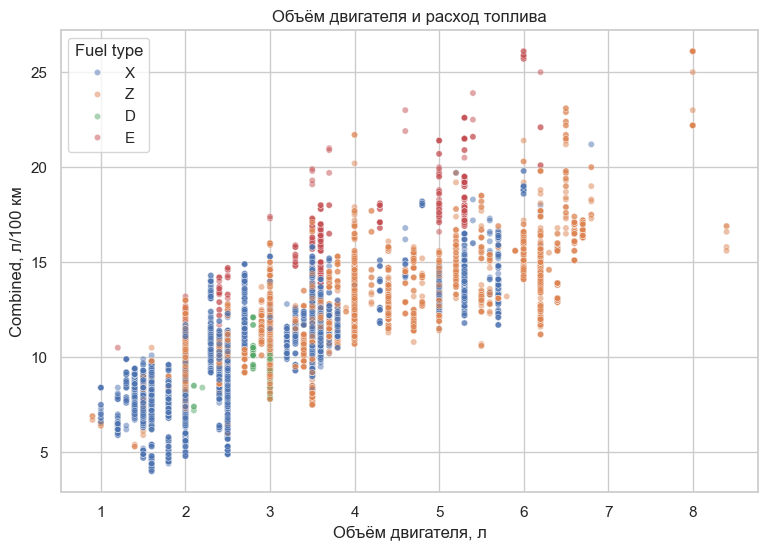

Корреляция Engine size и target: 0.811


In [41]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, x="Engine size (L)", y=TARGET,
    hue="Fuel type", hue_order=["X", "Z", "D", "E"],
    alpha=0.5, s=20
)
plt.title("Объём двигателя и расход топлива")
plt.xlabel("Объём двигателя, л")
plt.ylabel("Combined, л/100 км")
plt.show()

print("Корреляция Engine size и target:", round(df["Engine size (L)"].corr(df[TARGET]), 3))

**Вывод:**
- Связь сильная положительная, корреляция 0.81: больше двигатель, выше расход.
- При одном и том же объёме разброс большой (гибриды внизу, тяжёлые внедорожники вверху), значит одного объёма недостаточно, нужны класс автомобиля и тип топлива.
- Точки `E` (этанол E85) лежат выше остальных при том же объёме: это эффект топлива, а не двигателя.
- Для моделей: Linear Regression поймает общий тренд, Decision Tree и KNN лучше справятся с нелинейностью и влиянием `Fuel type`.

### 4.3 Корреляционная матрица

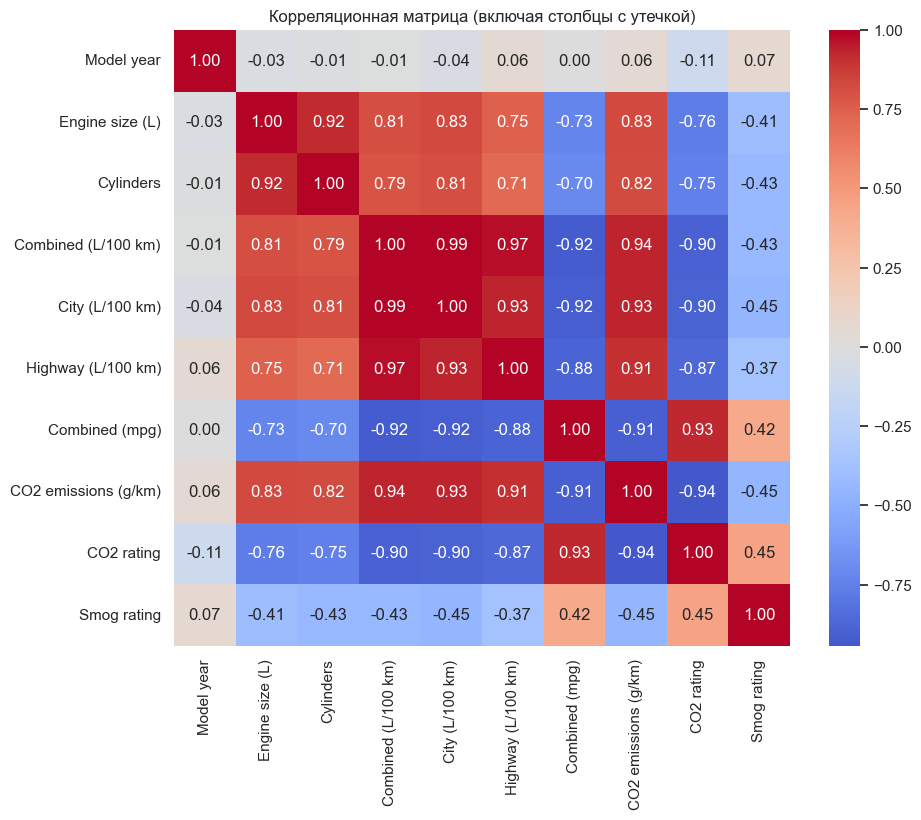

City (L/100 km)         0.992
Highway (L/100 km)      0.971
CO2 emissions (g/km)    0.939
Combined (mpg)         -0.922
CO2 rating             -0.902
Engine size (L)         0.811
Cylinders               0.789
Smog rating            -0.431
Model year             -0.006
Name: Combined (L/100 km), dtype: float64


In [42]:
num_cols = [
    "Model year", "Engine size (L)", "Cylinders", TARGET,
    "City (L/100 km)", "Highway (L/100 km)", "Combined (mpg)",
    "CO2 emissions (g/km)", "CO2 rating", "Smog rating",
]
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Корреляционная матрица (включая столбцы с утечкой)")
plt.show()

print(corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False).round(3))

**Вывод:**
- Столбцы из `leak_cols` почти идеально связаны с target: `City` 0.99, `Highway` 0.97, `CO2 emissions` 0.94, `Combined (mpg)` -0.92, `CO2 rating` -0.90. Они выражают target напрямую, поэтому исключаем их из признаков. `Smog rating` связан слабее (-0.43), его тоже исключаем (правило проекта, пропуски).
- Из допустимых признаков самые сильные: `Engine size` (0.81) и `Cylinders` (0.79).
- `Model year` почти не связан с target (-0.01).
- `Engine size` и `Cylinders` сильно коррелируют друг с другом (мультиколлинеарность): для деревьев и KNN не проблема, для Linear Regression учитываем при интерпретации коэффициентов.

### 4.4 Цилиндры и тип топлива

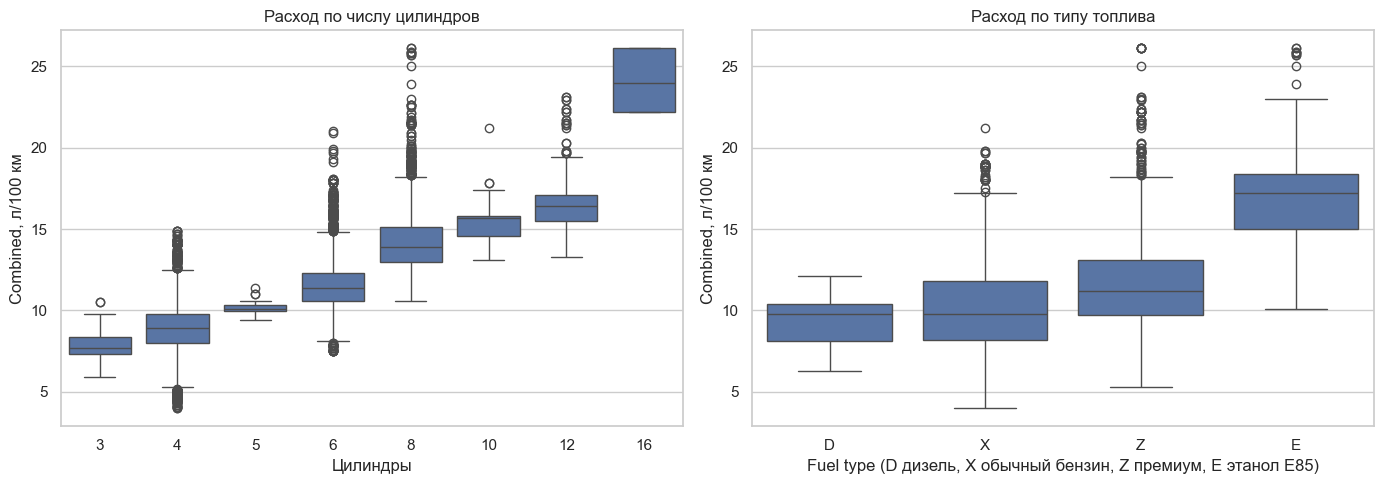

           count   mean
Cylinders              
3            197   7.74
4           5156   8.91
5             28  10.19
6           3835  11.58
8           2283  14.35
10            72  15.42
12           243  16.60
16            14  24.13
           count   mean
Fuel type              
D            272   9.31
E            423  16.97
X           5574  10.08
Z           5559  11.61


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x="Cylinders", y=TARGET, ax=axes[0])
axes[0].set_title("Расход по числу цилиндров")
axes[0].set_xlabel("Цилиндры")
axes[0].set_ylabel("Combined, л/100 км")

sns.boxplot(data=df, x="Fuel type", y=TARGET, order=["D", "X", "Z", "E"], ax=axes[1])
axes[1].set_title("Расход по типу топлива")
axes[1].set_xlabel("Fuel type (D дизель, X обычный бензин, Z премиум, E этанол E85)")
axes[1].set_ylabel("Combined, л/100 км")

plt.tight_layout()
plt.show()

print(df.groupby("Cylinders")[TARGET].agg(["count", "mean"]).round(2))
print(df.groupby("Fuel type")[TARGET].agg(["count", "mean"]).round(2))

**Вывод:**
- Расход растёт с числом цилиндров: в среднем 3 цил. 7.7, 4 цил. 8.9, 6 цил. 11.6, 8 цил. 14.4, 12 цил. 16.6 л/100 км.
- Группы очень разного размера: 4 цил. 5156 машин, 6 цил. 3835, 8 цил. 2283, а 5 цил. всего 28, 10 цил. 72, 16 цил. 14. В редких группах оценки менее надёжны, там ждём бóльших ошибок.
- Тип топлива сильно сдвигает расход: E 17.0, Z 11.6, X 10.1, D 9.3.
- Внутри групп разброс остаётся, значит нужны ещё класс и трансмиссия.
- Для моделей: `Fuel type` кодируем one-hot, `Cylinders` можно оставить числовым.

### 4.5 Годы и класс автомобиля

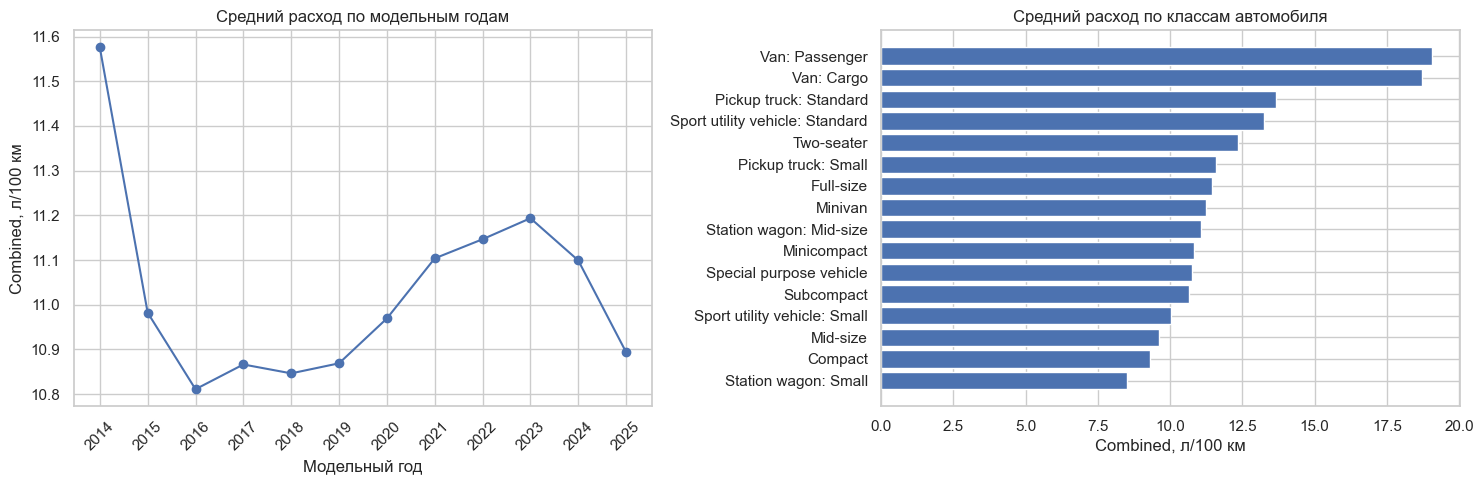

Model year
2014    11.58
2015    10.98
2016    10.81
2017    10.87
2018    10.85
2019    10.87
2020    10.97
2021    11.10
2022    11.15
2023    11.19
2024    11.10
2025    10.89
Name: Combined (L/100 km), dtype: float64
Vehicle class
Station wagon: Small                8.51
Compact                             9.29
Mid-size                            9.62
Sport utility vehicle: Small       10.02
Subcompact                         10.65
Special purpose vehicle            10.75
Minicompact                        10.82
Station wagon: Mid-size            11.06
Minivan                            11.23
Full-size                          11.45
Pickup truck: Small                11.60
Two-seater                         12.36
Sport utility vehicle: Standard    13.25
Pickup truck: Standard             13.65
Van: Cargo                         18.72
Van: Passenger                     19.08
Name: Combined (L/100 km), dtype: float64


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

yearly = df.groupby("Model year")[TARGET].mean()
axes[0].plot(yearly.index, yearly.values, marker="o")
axes[0].set_title("Средний расход по модельным годам")
axes[0].set_xlabel("Модельный год")
axes[0].set_ylabel("Combined, л/100 км")
axes[0].set_xticks(yearly.index)
axes[0].tick_params(axis="x", rotation=45)

by_class = df.groupby("Vehicle class")[TARGET].mean().sort_values()
axes[1].barh(by_class.index, by_class.values)
axes[1].set_title("Средний расход по классам автомобиля")
axes[1].set_xlabel("Combined, л/100 км")

plt.tight_layout()
plt.show()

print(yearly.round(2))
print(by_class.round(2))

**Вывод:**
- По годам: 2014 выделяется (11.58), с 2015 по 2025 расход почти не меняется (10.8-11.2). Повышение экономичности двигателей компенсируется ростом доли тяжёлых внедорожников и пикапов, поэтому корреляция с годом около нуля.
- Класс сильно влияет: самые экономичные `Station wagon: Small` (8.5), `Compact` (9.3), `Mid-size` (9.6); самые затратные `SUV: Standard` (13.3), `Pickup truck: Standard` (13.7), `Van: Cargo` (18.7), `Van: Passenger` (19.1).
- Фургоны редкие (22 и 70 машин), там возможны крупные ошибки.
- Для моделей: `Vehicle class` важный признак, кодируем one-hot. Ценность `Model year` решим при отборе признаков. Для group split помним, что одна модель повторяется в разные годы.

## Итог этапа 4
- **Target:** скошен вправо (среднее 11.03, медиана 10.7, std 2.88), мощный хвост до 26.1.
- **Сильные признаки:** `Engine size` (0.81), `Cylinders` (0.79), `Fuel type`, `Vehicle class`.
- **Слабый признак:** `Model year` (-0.01).
- **Leakage подтверждено:** 5 столбцов из `leak_cols` коррелируют с target на 0.90-0.99, исключаем при сборке признаков.
- **Мультиколлинеарность:** `Engine size` и `Cylinders`.
- **Редкие группы:** 5, 10 и 16 цилиндров; `Van: Cargo`, `Van: Passenger`; топливо E. Проверим их в error analysis.
- **Для этапа 5:** one-hot для `Fuel type` и `Vehicle class`, разбор `Transmission` на тип и число передач, масштабирование для KNN, новые признаки (тип трансмиссии, число передач, флаг гибрида по названию модели).